<a href="https://colab.research.google.com/github/Rogerio-mack/sync_nris/blob/main/gen_syntethic_nirs_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generate syntethic fnirs data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Generate a single subj and task, `gen_channels`

In [2]:
def df_c_from_dict(ground_truth):
  def replace_values(df_c):

    for i in range(len(df_c)):
      if df_c.iloc[i,1][0] == 'G':
        df_c.iloc[i,1] = df_c.iloc[i,1][1]

    nr_communities = len(df_c.community.unique())

    for i in range(len(df_c)):
      if df_c.iloc[i,1] == 'indep':
        df_c.iloc[i,1] = nr_communities + i

    df_c.community = df_c.community.astype(int)
    df_c

    return df_c

  df_c = pd.DataFrame()
  for key, values in ground_truth.items():
    df_temp = pd.DataFrame()
    df_temp['channel'] = values
    df_temp['community'] = key
    df_c = pd.concat([df_c, df_temp],ignore_index=True)

  return replace_values(df_c)


In [3]:
def gen_channels(seed=42,drive_1=0.035,drive_2=0.045,nr_1=3,nr_2=4,n_samples = 500):
  #
  import numpy as np
  import pandas as pd

  # 1. Configuração de reprodutibilidade e parâmetros temporais
  np.random.seed(seed)

  fs = 10.0          # Frequência de amostragem (Hz)
  time = np.arange(n_samples) / fs

  # 2. Oscilações hemodinâmicas subjacentes (Ground Truth Latente)
  # Grupo 1 oscila em torno de 0.035 Hz (banda hemodinâmica padrão)
  # Grupo 2 oscila em torno de 0.055 Hz

  driver_g1 = np.sin(2 * np.pi * drive_1 * time)
  driver_g2 = np.sin(2 * np.pi * drive_2 * time)

  channels = {}

  # -----------------------------------------------------------------
  # Grupo 1 (3 canais: Ch0, Ch1, Ch2) - Sincronizados em ~0.035 Hz
  # Inclui defasagens angulares leves e ruído instrumental/fisiológico
  # -----------------------------------------------------------------
  ground_truth = {}
  ground_truth['indep'] = list()
  if nr_1 == 3:
    channels['SD0'] = 1.00 * driver_g1 + 0.35 * np.random.randn(n_samples)
    channels['SD1'] = channels['SD0'] + 0.1 * np.random.randn(n_samples)
    channels['SD1'] = -channels['SD1'] + channels['SD1'].max()
    channels['SD2'] = channels['SD0'] + 0.2 * np.random.randn(n_samples)

    ground_truth['G1'] = ['SD0', 'SD1', 'SD2']
  elif nr_1 == 2:
    channels['SD0'] = 1.00 * driver_g1 + 0.35 * np.random.randn(n_samples)
    channels['SD1'] = channels['SD0'] + 0.1 * np.random.randn(n_samples)
    channels['SD1'] = -channels['SD1'] + channels['SD1'].max()
    channels['SD2'] = 0.05 * np.random.randn(n_samples)

    ground_truth['G1'] = ['SD0', 'SD1']
    ground_truth['indep'].append('SD2')
  elif nr_1 == 1:
    channels['SD0'] = 1.00 * driver_g1 + 0.35 * np.random.randn(n_samples)
    channels['SD1'] = 0.15 * np.random.randn(n_samples)
    channels['SD2'] = 0.25 * np.random.randn(n_samples)

    ground_truth['G1'] = ['SD0']
    ground_truth['indep'].append('SD1')
    ground_truth['indep'].append('SD2')

  # -----------------------------------------------------------------
  # Grupo 2 (4 canais: Ch3, Ch4, Ch5, Ch6) - Sincronizados em ~0.055 Hz
  # Inclui defasagens distintas e variações de amplitude
  # -----------------------------------------------------------------
  np.random.seed(seed+1)
  if nr_2 == 4:
    channels['SD3'] = 1.00 * driver_g2 + 0.35 * np.random.randn(n_samples)
    channels['SD4'] = channels['SD3'] + 0.1 * np.random.randn(n_samples)
    channels['SD4'] = -channels['SD4'] + channels['SD4'].max()
    channels['SD5'] = channels['SD3'] + 0.2 * np.random.randn(n_samples)
    channels['SD6'] = channels['SD3'] + 0.3 * np.random.randn(n_samples)

    ground_truth['G2'] = ['SD3', 'SD4', 'SD5', 'SD6']
  elif nr_2 == 3:
    channels['SD3'] = 1.00 * driver_g2 + 0.35 * np.random.randn(n_samples)
    channels['SD4'] = channels['SD3'] + 0.1 * np.random.randn(n_samples)
    channels['SD4'] = -channels['SD4'] + channels['SD4'].max()
    channels['SD5'] = channels['SD3'] + 0.2 * np.random.randn(n_samples)
    channels['SD6'] = 0.35 * np.random.randn(n_samples)

    ground_truth['G2'] = ['SD3', 'SD4', 'SD5']
    ground_truth['indep'].append('SD6')
  elif nr_2 == 2:
    channels['SD3'] = 1.00 * driver_g2 + 0.35 * np.random.randn(n_samples)
    channels['SD4'] = channels['SD3'] + 0.1 * np.random.randn(n_samples)
    channels['SD4'] = -channels['SD4'] + channels['SD4'].max()
    channels['SD5'] = 0.45 * np.random.randn(n_samples)
    channels['SD6'] = 0.55 * np.random.randn(n_samples)

    ground_truth['G2'] = ['SD3', 'SD4']
    ground_truth['indep'].append('SD5')
    ground_truth['indep'].append('SD6')
  elif nr_2 == 1:
    channels['SD3'] = 1.00 * driver_g2 + 0.35 * np.random.randn(n_samples)

    channels['SD4'] = 0.65 * np.random.randn(n_samples)
    channels['SD5'] = 0.75 * np.random.randn(n_samples)
    channels['SD6'] = 0.85 * np.random.randn(n_samples)
    ground_truth['G2'] = ['SD3']
    ground_truth['indep'].append('SD4')
    ground_truth['indep'].append('SD5')
    ground_truth['indep'].append('SD6')

  # -----------------------------------------------------------------
  # Canais Independentes (3 canais: Ch7, Ch8, Ch9)
  # Frequências desacopladas e ruído branco não correlacionado
  # -----------------------------------------------------------------
  np.random.seed(seed+2)
  channels['SD7'] = 0.90 * np.sin(2 * np.pi * 0.015 * time) + 0.60 * np.random.randn(n_samples)
  channels['SD8'] = 0.95 * np.sin(2 * np.pi * 0.085 * time) + 0.60 * np.random.randn(n_samples)
  channels['SD9'] = 1.00 * np.random.randn(n_samples)

  ground_truth['indep'].append('SD7')
  ground_truth['indep'].append('SD8')
  ground_truth['indep'].append('SD9')

  # 3. Montagem do DataFrame e exportação
  df = pd.DataFrame(channels)
  df.insert(0, 'time', np.round(time, 3))

  df_communities_ground_truth = df_c_from_dict(ground_truth)

  return df, ground_truth, df_communities_ground_truth

df, ground_truth, df_communities_ground_truth = gen_channels(seed=42,drive_1=0.035,drive_2=0.045,nr_1=3,nr_2=4,n_samples = 500)
display(df.head())
print()
display(ground_truth)
print()
display(df_communities_ground_truth.head())
print()
display(df_communities_ground_truth.groupby(['community']).count())

,time,SD0,SD1,SD2,SD3,SD4,SD5,SD6,SD7,SD8,SD9
0,0.0,0.173850,1.439444,0.453721,0.090090,1.880227,0.249911,0.535990,-0.450369,-0.041995,-0.275822
1,0.1,-0.026403,1.541374,0.158524,-0.289698,1.961922,-0.246487,-0.145328,0.798297,-0.379475,1.719652
2,0.2,0.270659,1.575110,0.282585,-0.075958,1.894357,0.124004,-0.544744,0.764648,-0.493876,-0.623913
3,0.3,0.598986,1.050629,0.469599,-0.102499,1.882283,0.024815,0.332205,-0.937506,-0.035908,0.963907
4,0.4,0.005898,1.765079,0.145542,0.413182,1.477168,0.384076,1.069364,-0.846965,0.274944,-0.122699


{'indep': ['SD7', 'SD8', 'SD9'],
 'G1': ['SD0', 'SD1', 'SD2'],
 'G2': ['SD3', 'SD4', 'SD5', 'SD6']}

,channel,community
0,SD7,3
1,SD8,4
2,SD9,5
3,SD0,1
4,SD1,1


,channel
community,
1,3
2,4
3,1
4,1
5,1


## Plot single subj and task

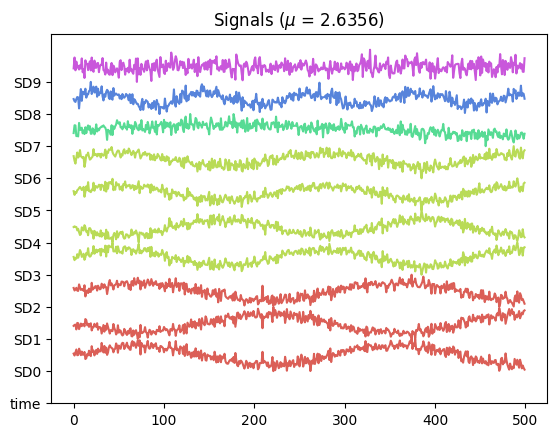

In [4]:
from sklearn.preprocessing import minmax_scale

nr_communities = len(df_communities_ground_truth.community.unique())

cmap = sns.color_palette("hls", nr_communities)

for coluna in range(1,len(df.columns)):
  community_idx = df_communities_ground_truth[ df_communities_ground_truth.channel == df.columns[coluna] ].community.values[0]
  plt.plot(minmax_scale(df.iloc[:,coluna])+coluna, color=cmap[community_idx-1])

  plt.yticks(ticks=range(0,df.shape[1]), labels=df.columns[0:df.shape[1]])
  plt.title(f'Signals ($\\mu$ = {df.mean().mean():.4f})')

plt.show()

# Generate multiple subjs and tasks

In [5]:
data = pd.DataFrame()
ground_truth = {}

df, g, _ = gen_channels(seed=42,drive_1=0.035,drive_2=0.045,nr_1=3,nr_2=4)
df.insert(0, 'task', 'A')
df.insert(0, 'subj', 1)
data = pd.concat([data, df],ignore_index=True)
ground_truth[1] = {}
ground_truth[1]['A'] = g

df, g, _ = gen_channels(seed=50,drive_1=0.035,drive_2=0.045,nr_1=3,nr_2=4)
df.insert(0, 'task', 'B')
df.insert(0, 'subj', 1)
data = pd.concat([data, df],ignore_index=True)
ground_truth[1]['B'] = g

df, g, _ = gen_channels(seed=1,drive_1=0.045,drive_2=0.035,nr_1=2,nr_2=4)
df.insert(0, 'task', 'A')
df.insert(0, 'subj', 2)
data = pd.concat([data, df],ignore_index=True)
ground_truth[2] = {}
ground_truth[2]['A'] = g

df, g, _ = gen_channels(seed=9,drive_1=0.045,drive_2=0.035,nr_1=3,nr_2=3)
df.insert(0, 'task', 'B')
df.insert(0, 'subj', 2)
data = pd.concat([data, df],ignore_index=True)
ground_truth[2]['B'] = g

df, g, _ = gen_channels(seed=68,drive_1=0.030,drive_2=0.0405,nr_1=2,nr_2=2)
df.insert(0, 'task', 'A')
df.insert(0, 'subj', 3)
data = pd.concat([data, df],ignore_index=True)
ground_truth[3] = {}
ground_truth[3]['A'] = g

df, g, _ = gen_channels(seed=1968,drive_1=0.030,drive_2=0.040,nr_1=2,nr_2=2)
df.insert(0, 'task', 'B')
df.insert(0, 'subj', 3)
data = pd.concat([data, df],ignore_index=True)
ground_truth[3]['B'] = g

data.reset_index(drop=True, inplace=True)

df = data.copy()

display(df.head())
print()
display(ground_truth)
print()
df.subj.value_counts(), df.task.value_counts(), df.shape


,subj,task,time,SD0,SD1,SD2,SD3,SD4,SD5,SD6,SD7,SD8,SD9
0,1,A,0.0,0.173850,1.439444,0.453721,0.090090,1.880227,0.249911,0.535990,-0.450369,-0.041995,-0.275822
1,1,A,0.1,-0.026403,1.541374,0.158524,-0.289698,1.961922,-0.246487,-0.145328,0.798297,-0.379475,1.719652
2,1,A,0.2,0.270659,1.575110,0.282585,-0.075958,1.894357,0.124004,-0.544744,0.764648,-0.493876,-0.623913
3,1,A,0.3,0.598986,1.050629,0.469599,-0.102499,1.882283,0.024815,0.332205,-0.937506,-0.035908,0.963907
4,1,A,0.4,0.005898,1.765079,0.145542,0.413182,1.477168,0.384076,1.069364,-0.846965,0.274944,-0.122699


{1: {'A': {'indep': ['SD7', 'SD8', 'SD9'],
   'G1': ['SD0', 'SD1', 'SD2'],
   'G2': ['SD3', 'SD4', 'SD5', 'SD6']},
  'B': {'indep': ['SD7', 'SD8', 'SD9'],
   'G1': ['SD0', 'SD1', 'SD2'],
   'G2': ['SD3', 'SD4', 'SD5', 'SD6']}},
 2: {'A': {'indep': ['SD2', 'SD7', 'SD8', 'SD9'],
   'G1': ['SD0', 'SD1'],
   'G2': ['SD3', 'SD4', 'SD5', 'SD6']},
  'B': {'indep': ['SD6', 'SD7', 'SD8', 'SD9'],
   'G1': ['SD0', 'SD1', 'SD2'],
   'G2': ['SD3', 'SD4', 'SD5']}},
 3: {'A': {'indep': ['SD2', 'SD5', 'SD6', 'SD7', 'SD8', 'SD9'],
   'G1': ['SD0', 'SD1'],
   'G2': ['SD3', 'SD4']},
  'B': {'indep': ['SD2', 'SD5', 'SD6', 'SD7', 'SD8', 'SD9'],
   'G1': ['SD0', 'SD1'],
   'G2': ['SD3', 'SD4']}}}

(subj
 1    1000
 2    1000
 3    1000
 Name: count, dtype: int64,
 task
 A    1500
 B    1500
 Name: count, dtype: int64,
 (3000, 13))

In [6]:
df_communities_ground_truth = pd.DataFrame()

df_temp = pd.DataFrame()
for subj, tasks in ground_truth.items():
  # print(f"Subject {subj}")
  # print(f"Tasks: {tasks}")
  # print()
  df_temp2 = pd.DataFrame()
  for task, channels in tasks.items():
    # print(f"Task {task}")
    # print(f"Channels: {channels}")
    # print()
    df_temp3 = df_c_from_dict(channels)
    df_temp3['task'] = task
    df_temp2 = pd.concat([df_temp2, df_temp3],ignore_index=True)

  df_temp2['subj'] = subj
  df_temp = pd.concat([df_temp, df_temp2],ignore_index=True)

df_communities_ground_truth = df_temp
df_communities_ground_truth = df_communities_ground_truth[['subj','task','channel','community']]
df_communities_ground_truth = df_communities_ground_truth.sort_values(by=['subj','task'])

display(df_communities_ground_truth.head())

df_communities_ground_truth.groupby(['subj','task']).channel.count()

,subj,task,channel,community
0,1,A,SD7,3
1,1,A,SD8,4
2,1,A,SD9,5
3,1,A,SD0,1
4,1,A,SD1,1


subj  task
1     A       10
      B       10
2     A       10
      B       10
3     A       10
      B       10
Name: channel, dtype: int64

In [7]:
sel_subj_task = (df_communities_ground_truth.subj == 2) & (df_communities_ground_truth.task == 'A')

df_communities_ground_truth[sel_subj_task]

,subj,task,channel,community
20,2,A,SD2,3
21,2,A,SD7,4
22,2,A,SD8,5
23,2,A,SD9,6
24,2,A,SD0,1
25,2,A,SD1,1
26,2,A,SD3,2
27,2,A,SD4,2
28,2,A,SD5,2
29,2,A,SD6,2


## Plot subjs and tasks

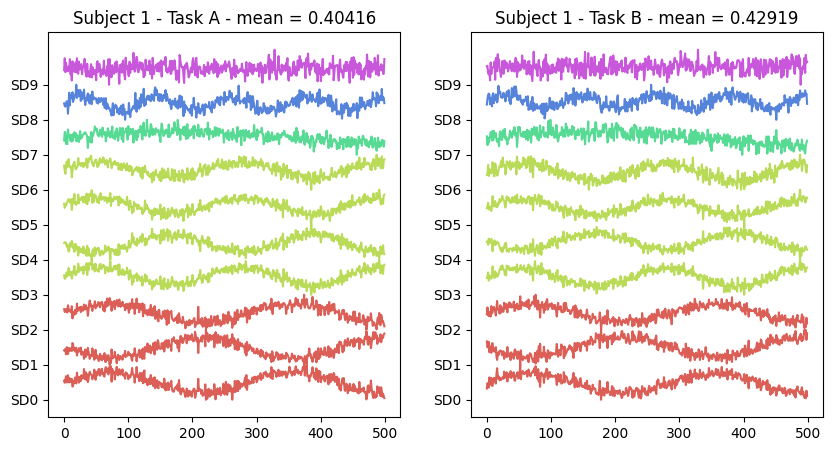

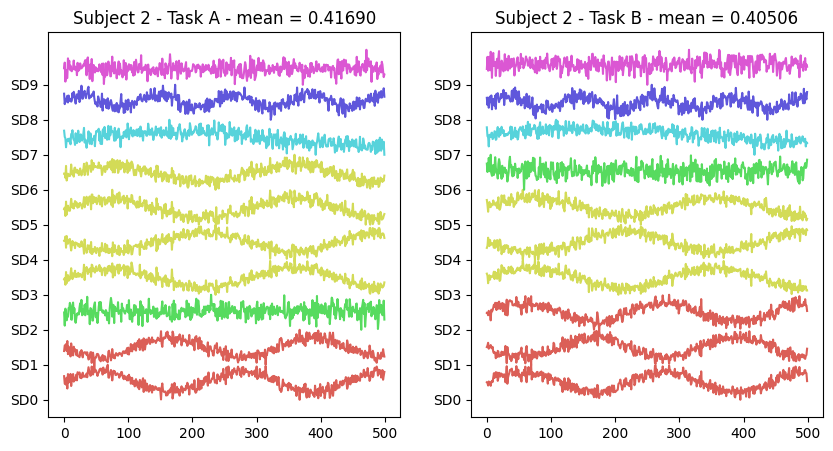

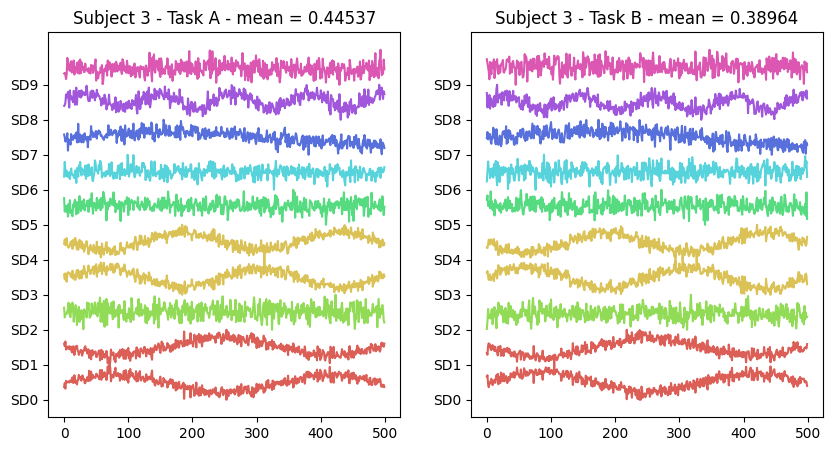

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.preprocessing import minmax_scale

nr_communities = len(df_communities_ground_truth.community.unique())

cmap = sns.color_palette("hls", nr_communities)

for s in df.subj.unique():
  plt.figure(figsize=(10,5))
  task_nr = 1
  for t in df.task.unique():

    sel_subj_task = (df_communities_ground_truth.subj == s) & (df_communities_ground_truth.task == t)
    df_communities_subj_task = df_communities_ground_truth[sel_subj_task]
    nr_communities = len(df_communities_subj_task.community.unique())
    cmap = sns.color_palette("hls", nr_communities)

    df_temp = df[(df.task == t) & (df.subj == s)]
    df_temp = df_temp.drop(columns=['subj','time','task'])

    for coluna in range(len(df_temp.columns)):
      community_idx = df_communities_subj_task[ df_communities_subj_task.channel == df_temp.columns[coluna] ].community.values[0]
      plt.subplot(1,len(df.task.unique()),task_nr)
      plt.plot(minmax_scale(df_temp.iloc[:,coluna])+coluna, color=cmap[community_idx-1])

      plt.yticks(ticks=range(0,df_temp.shape[1]), labels=df_temp.columns[0:df_temp.shape[1]])
      plt.title(f'Subject {s} - Task {t} - mean = {df_temp.mean().mean():.5f}')
    task_nr = task_nr + 1
  plt.show()


# Save

In [9]:
fname = 'fnirs_synthetic_10ch_groundtruth.csv'
df.to_csv(fname, index=False)

In [10]:
from google.colab import files
files.download(fname)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>